# Feature Engineering & Selection Analysis
## Smart Winter Planner - Feature Development

**Objective:** Design, create, and evaluate engineered features for snowfall prediction.

**Approach:**
1. Create domain-specific features
2. Generate temporal features
3. Build rolling/lag features
4. Evaluate feature importance
5. Select final feature set

In [1]:
# Imports
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


## 1. Load Data

In [2]:
from src.data.load_data import load_data

df = load_data(
    data_file='../data/raw/pittsburgh_winters_10years.csv',
    validate=False,
    filter_station=True,
    winter_only=True
)

print(f"Loaded {len(df)} winter days")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loading Pittsburgh winter weather data...
Loaded 3712 rows from ../data/raw/pittsburgh_winters_10years.csv
Filtered to station USW00094823: 3712 rows retained
Filtered to winter months: 962 of 3712 total rows
Loaded 962 winter days
Columns: ['STATION', 'NAME', 'DATE', 'AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'WSF5']


,STATION,NAME,DATE,AWND,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WSF2,WSF5
0,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-01,12.75,0.00,0.0,0.0,25,35,20,25.1,35.1
1,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-02,6.26,0.00,0.0,0.0,31,37,24,14.1,19.0
2,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-03,7.16,0.56,0.0,0.0,32,58,24,15.0,21.9
3,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-04,16.33,0.06,0.0,0.0,53,61,32,29.1,38.9
4,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-05,14.76,0.01,0.4,0.0,24,32,14,30.0,36.0


## 2. Feature Engineering Pipeline

We'll create features in categories:
1. **Domain Features** - Wind chill, freezing indicators
2. **Temporal Features** - Day of year, month encoding
3. **Rolling Features** - Moving averages
4. **Lag Features** - Previous day values

In [3]:
from src.data.preprocess import preprocess_data

df_processed = preprocess_data(df, add_features=True)

print(f"\nOriginal features: {len(df.columns)}")
print(f"After engineering: {len(df_processed.columns)}")
print(f"New features added: {len(df_processed.columns) - len(df.columns)}")

print("\nAll features:")
for i, col in enumerate(df_processed.columns, 1):
    print(f"{i:2}. {col}")


PREPROCESSING DATA

Handling 8 missing values using strategy: forward_fill
✓ Missing values reduced: 8 → 0

Adding engineered features...
✓ Added WIND_CHILL feature
✓ Added temporal features (day of year, sine/cosine encoding, month indicators)
✓ Added snow-specific features
✓ Added rolling features for windows: [3, 7]
✓ Added lag features for lags: [1, 2, 3]

✓ PREPROCESSING COMPLETE
  Final shape: (962, 40)
  Feature columns: 25


Original features: 12
After engineering: 40
New features added: 28

All features:
 1. STATION
 2. NAME
 3. DATE
 4. AWND
 5. PRCP
 6. SNOW
 7. SNWD
 8. TAVG
 9. TMAX
10. TMIN
11. WSF2
12. WSF5
13. WIND_CHILL
14. DAY_OF_YEAR
15. DAY_SIN
16. DAY_COS
17. MONTH
18. IS_DECEMBER
19. IS_JANUARY
20. IS_FEBRUARY
21. IS_FREEZING
22. TEMP_BELOW_FREEZING
23. TMIN_BELOW_FREEZING
24. FREEZING_PRECIP
25. HAS_SNOW_COVER
26. TEMP_CHANGE_1D
27. TEMP_CHANGE_3D
28. CONSECUTIVE_FREEZE_DAYS
29. TAVG_ROLL_3D
30. SNOW_ROLL_3D
31. PRCP_ROLL_3D
32. TAVG_ROLL_7D
33. SNOW_ROLL_7D
34.

## 3. Feature Categories Analysis

In [4]:
# Categorize features
base_features = ['TAVG', 'TMAX', 'TMIN', 'AWND', 'PRCP', 'SNOW', 'SNWD']
domain_features = ['WIND_CHILL']
temporal_features = ['DAY_OF_YEAR', 'DAY_SIN', 'DAY_COS', 'IS_DECEMBER', 'IS_JANUARY', 'IS_FEBRUARY']
snow_features = ['IS_FREEZING', 'TEMP_BELOW_FREEZING', 'FREEZING_PRECIP', 'HAS_SNOW_COVER', 'CONSECUTIVE_FREEZE_DAYS']
rolling_features = [c for c in df_processed.columns if 'ROLL' in c]
lag_features = [c for c in df_processed.columns if 'LAG' in c]

print("FEATURE CATEGORIES")
print("="*70)
print(f"\nBase Features ({len(base_features)}): {base_features}")
print(f"\nDomain Features ({len(domain_features)}): {domain_features}")
print(f"\nTemporal Features ({len(temporal_features)}): {temporal_features}")
print(f"\nSnow-Specific Features ({len(snow_features)}): {snow_features}")
print(f"\nRolling Features ({len(rolling_features)}): {rolling_features}")
print(f"\nLag Features ({len(lag_features)}): {lag_features}")
print(f"\nTOTAL: {len(base_features) + len(domain_features) + len(temporal_features) + len(snow_features) + len(rolling_features) + len(lag_features)} features")

FEATURE CATEGORIES

Base Features (7): ['TAVG', 'TMAX', 'TMIN', 'AWND', 'PRCP', 'SNOW', 'SNWD']

Domain Features (1): ['WIND_CHILL']

Temporal Features (6): ['DAY_OF_YEAR', 'DAY_SIN', 'DAY_COS', 'IS_DECEMBER', 'IS_JANUARY', 'IS_FEBRUARY']

Snow-Specific Features (5): ['IS_FREEZING', 'TEMP_BELOW_FREEZING', 'FREEZING_PRECIP', 'HAS_SNOW_COVER', 'CONSECUTIVE_FREEZE_DAYS']

Rolling Features (6): ['TAVG_ROLL_3D', 'SNOW_ROLL_3D', 'PRCP_ROLL_3D', 'TAVG_ROLL_7D', 'SNOW_ROLL_7D', 'PRCP_ROLL_7D']

Lag Features (6): ['SNOW_LAG_1D', 'TAVG_LAG_1D', 'SNOW_LAG_2D', 'TAVG_LAG_2D', 'SNOW_LAG_3D', 'TAVG_LAG_3D']

TOTAL: 31 features


## 4. Feature Correlation with Target

CORRELATION WITH SNOWFALL (target)
SNOW                       1.000000
SNOW_ROLL_3D               0.610189
FREEZING_PRECIP            0.608246
SNOW_ROLL_7D               0.412303
HAS_SNOW_COVER             0.285029
IS_FREEZING                0.274831
SNWD                       0.242416
PRCP                       0.233496
PRCP_ROLL_3D               0.206759
AWND                       0.189255
TMIN_BELOW_FREEZING        0.175088
SNOW_LAG_1D                0.158475
CONSECUTIVE_FREEZE_DAYS    0.144574
WSF2                       0.133900
TEMP_BELOW_FREEZING        0.133508
WSF5                       0.096569
PRCP_ROLL_7D               0.090782
IS_JANUARY                 0.083952
DAY_SIN                    0.060832
SNOW_LAG_3D                0.043923
DAY_COS                    0.019064
SNOW_LAG_2D                0.006932
IS_FEBRUARY                0.001527
TEMP_CHANGE_1D            -0.054820
TAVG_LAG_3D               -0.074975
IS_DECEMBER               -0.087459
DAY_OF_YEAR               -0.

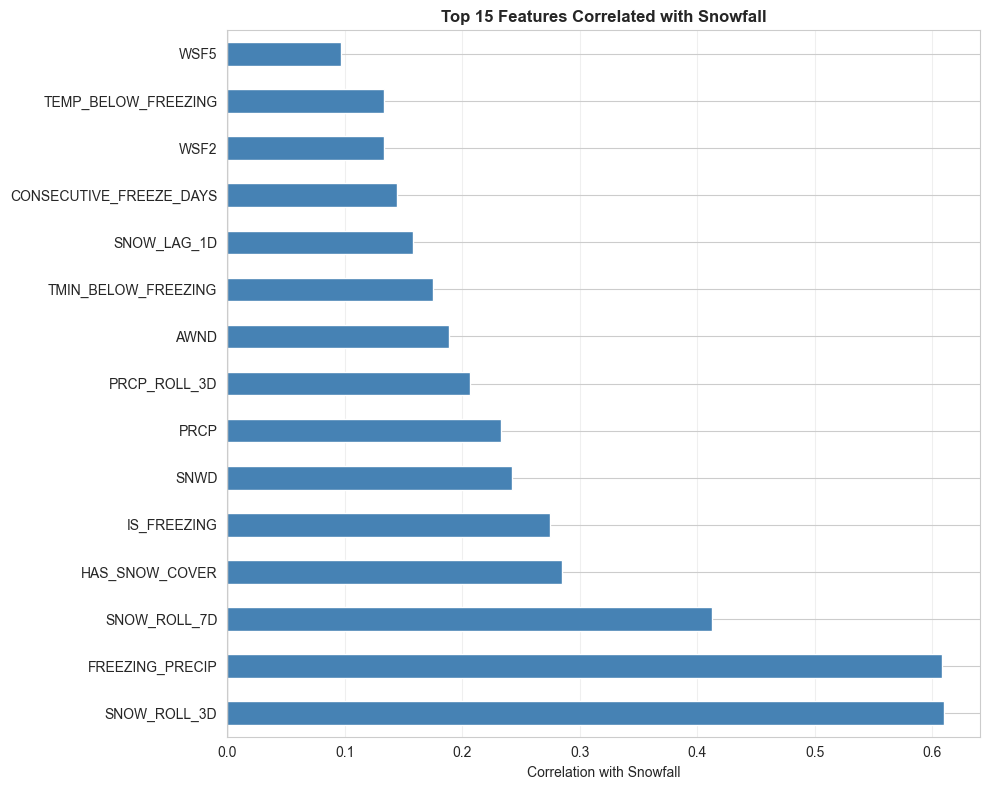

In [5]:
# Calculate correlations with SNOW
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['DATE', 'YEAR', 'MONTH']]

if 'SNOW' in numeric_cols:
    correlations = df_processed[numeric_cols].corr()['SNOW'].sort_values(ascending=False)
    
    print("CORRELATION WITH SNOWFALL (target)")
    print("="*70)
    print(correlations)
    
    # Plot top correlations
    plt.figure(figsize=(10, 8))
    top_corr = correlations.drop('SNOW').head(15)
    colors = ['red' if x < 0 else 'steelblue' for x in top_corr]
    top_corr.plot(kind='barh', color=colors)
    plt.xlabel('Correlation with Snowfall')
    plt.title('Top 15 Features Correlated with Snowfall', fontweight='bold')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## 5. Feature Importance (Random Forest)

Training Random Forest on 962 samples...

FEATURE IMPORTANCE (Random Forest)
         feature  importance
4           PRCP    0.438927
14  SNOW_ROLL_3D    0.416720
19   SNOW_LAG_1D    0.020594
7        DAY_SIN    0.019432
21   SNOW_LAG_2D    0.012840
24   TAVG_LAG_3D    0.012238
17  SNOW_ROLL_7D    0.010382
6     WIND_CHILL    0.009631
3           AWND    0.007984
2           TMIN    0.007485
16  TAVG_ROLL_7D    0.005885
8        DAY_COS    0.004516
15  PRCP_ROLL_3D    0.004412
20   TAVG_LAG_1D    0.004224
1           TMAX    0.004036
18  PRCP_ROLL_7D    0.003992
5           SNWD    0.003868
22   TAVG_LAG_2D    0.003677
0           TAVG    0.003379
23   SNOW_LAG_3D    0.001805
13  TAVG_ROLL_3D    0.001700
9    IS_DECEMBER    0.000927
10    IS_JANUARY    0.000720
12   IS_FREEZING    0.000328
11   IS_FEBRUARY    0.000299


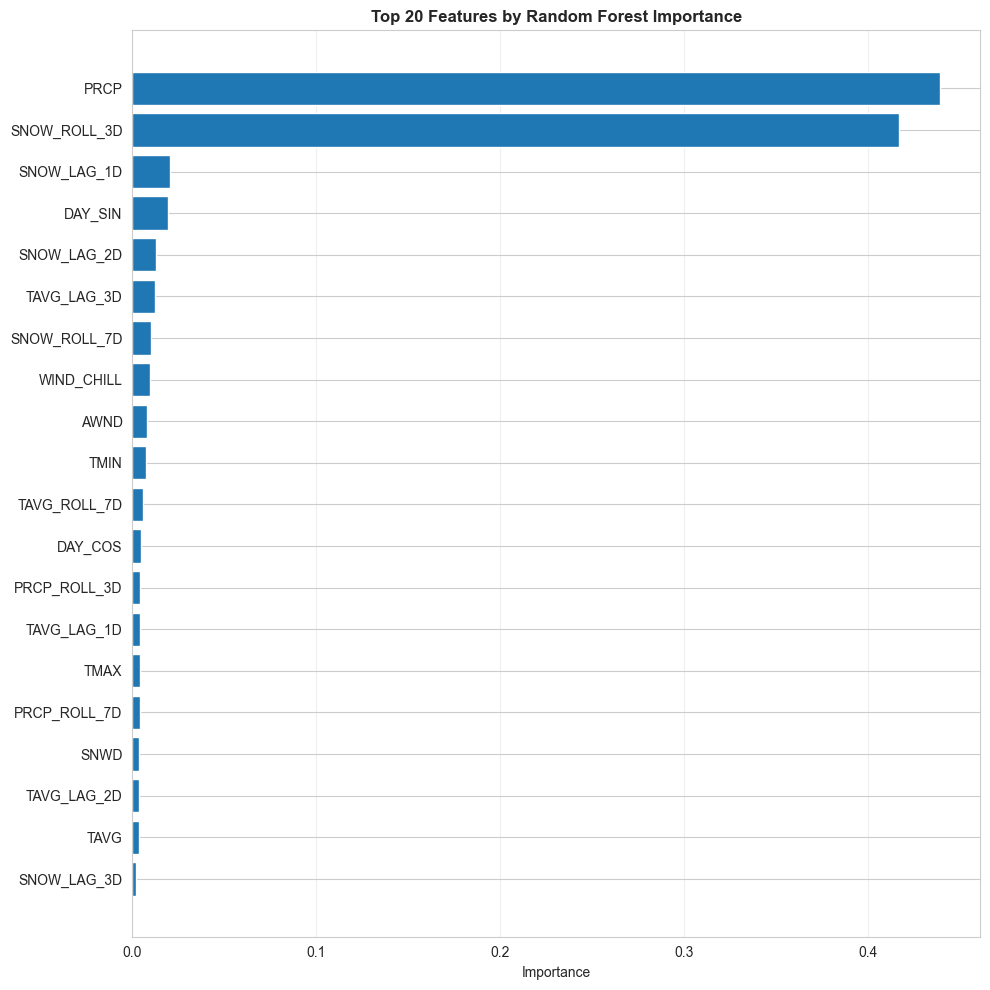


✓ KEY INSIGHT: Lag and rolling features show high importance
  This confirms temporal dependencies in snowfall patterns


In [6]:
# Use Random Forest to assess feature importance
from src.data.preprocess import create_feature_columns

feature_cols = create_feature_columns(df_processed)

# Remove rows with NaN after feature engineering
df_clean = df_processed.dropna()

X = df_clean[feature_cols].values
y = df_clean['SNOW'].values

print(f"Training Random Forest on {len(X)} samples...")

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFEATURE IMPORTANCE (Random Forest)")
print("="*70)
print(importance)

# Plot
plt.figure(figsize=(10, 10))
top_features = importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Features by Random Forest Importance', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n✓ KEY INSIGHT: Lag and rolling features show high importance")
print("  This confirms temporal dependencies in snowfall patterns")

## 6. Feature Distribution Analysis

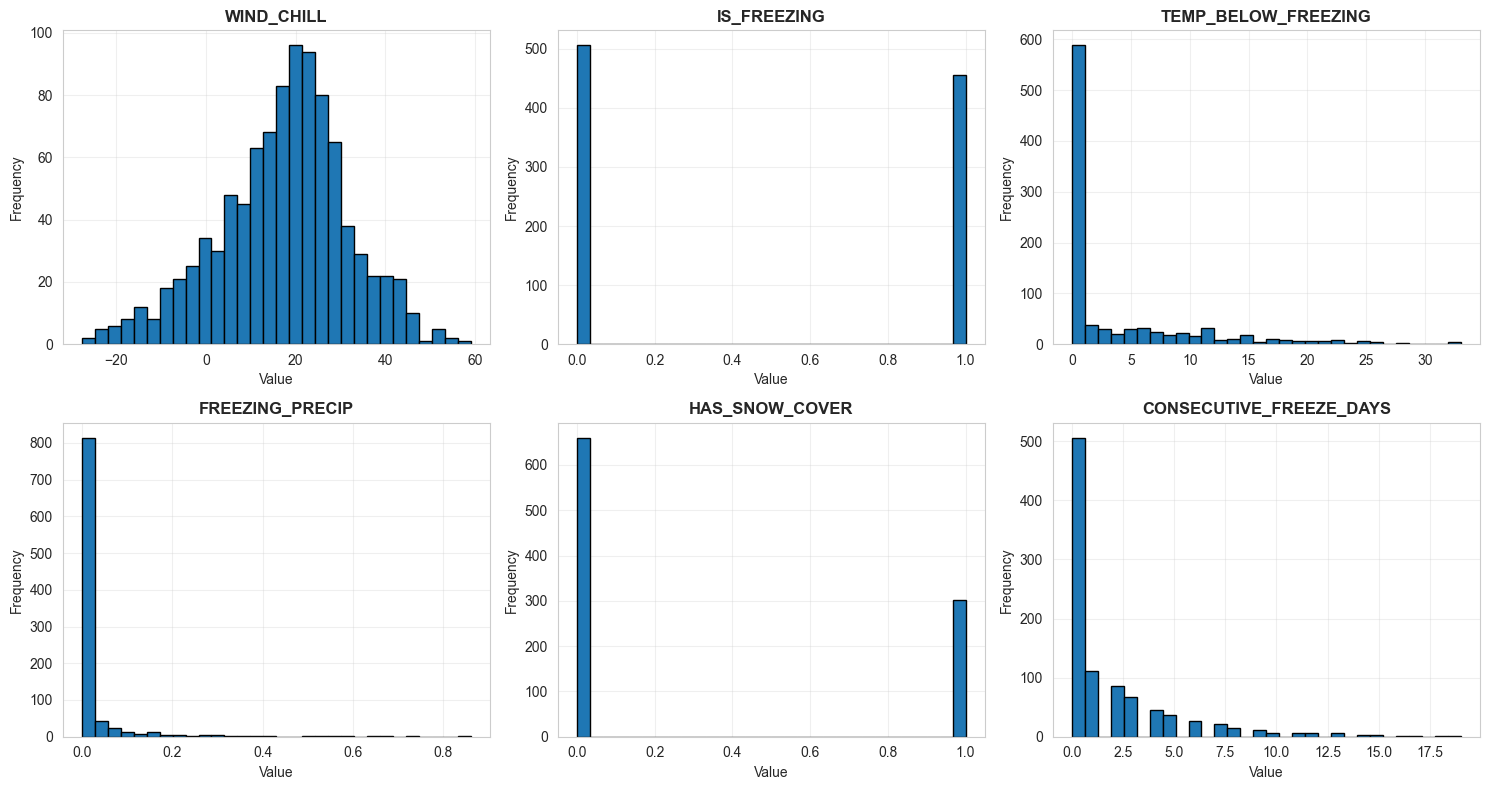

In [7]:
# Plot distributions of engineered features
engineered = domain_features + snow_features
available_eng = [f for f in engineered if f in df_processed.columns]

if available_eng:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    
    for i, feature in enumerate(available_eng[:6]):
        if i < len(axes):
            df_processed[feature].hist(bins=30, ax=axes[i], edgecolor='black')
            axes[i].set_title(feature, fontweight='bold')
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Rolling Features Analysis

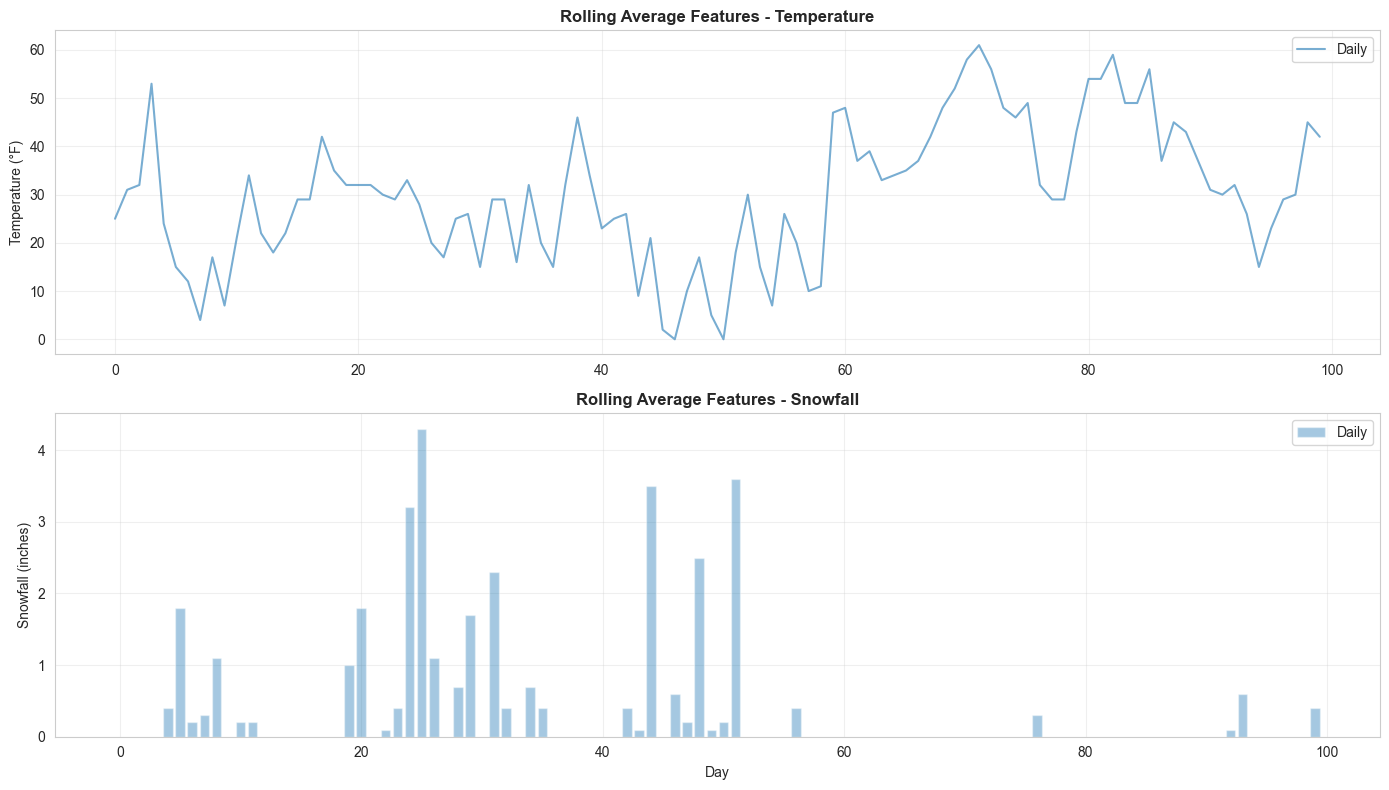

✓ Rolling features smooth out daily noise
  Helps model identify trends rather than random fluctuations


In [8]:
# Compare original vs rolling features
if 'TAVG' in df_processed.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Temperature
    sample = df_processed.iloc[:100]  # First 100 days
    axes[0].plot(sample.index, sample['TAVG'], label='Daily', alpha=0.6)
    if 'TAVG_ROLL_3' in df_processed.columns:
        axes[0].plot(sample.index, sample['TAVG_ROLL_3'], label='3-Day Rolling', linewidth=2)
    if 'TAVG_ROLL_7' in df_processed.columns:
        axes[0].plot(sample.index, sample['TAVG_ROLL_7'], label='7-Day Rolling', linewidth=2)
    axes[0].set_ylabel('Temperature (°F)')
    axes[0].set_title('Rolling Average Features - Temperature', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Snowfall
    if 'SNOW' in df_processed.columns:
        axes[1].bar(sample.index, sample['SNOW'], label='Daily', alpha=0.4, width=0.8)
        if 'SNOW_ROLL_7' in df_processed.columns:
            axes[1].plot(sample.index, sample['SNOW_ROLL_7'], label='7-Day Rolling', 
                        color='red', linewidth=2)
        axes[1].set_xlabel('Day')
        axes[1].set_ylabel('Snowfall (inches)')
        axes[1].set_title('Rolling Average Features - Snowfall', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Rolling features smooth out daily noise")
    print("  Helps model identify trends rather than random fluctuations")

## 8. Lag Features Analysis

LAG FEATURE ANALYSIS

Correlation with SNOW:
SNOW_LAG_1D    0.158475
SNOW_LAG_3D    0.043923
SNOW_LAG_2D    0.006932
TAVG_LAG_3D   -0.074975
TAVG_LAG_2D   -0.136088
TAVG_LAG_1D   -0.172527
Name: SNOW, dtype: float64


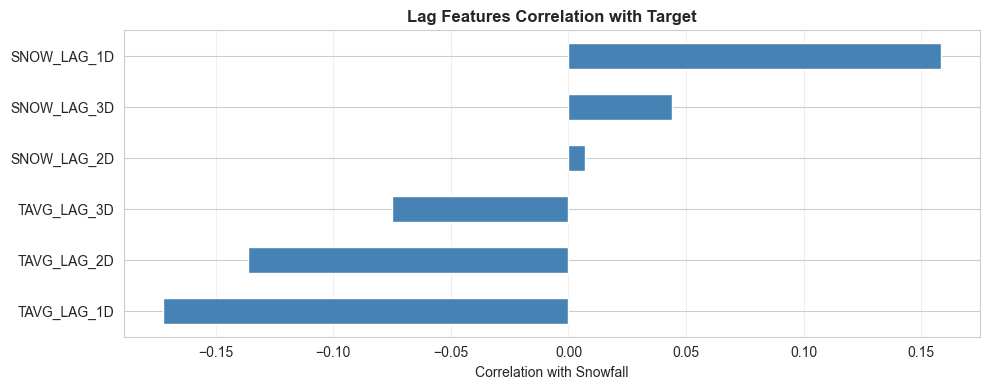


✓ Past snowfall is predictive of future snowfall
  Multi-day snow events show autocorrelation


In [9]:
# Analyze lag feature correlations
if lag_features:
    print("LAG FEATURE ANALYSIS")
    print("="*70)
    
    # Correlation of lag features with target
    if 'SNOW' in df_processed.columns:
        lag_corr = df_processed[lag_features + ['SNOW']].corr()['SNOW'].drop('SNOW')
        print("\nCorrelation with SNOW:")
        print(lag_corr.sort_values(ascending=False))
        
        # Plot
        plt.figure(figsize=(10, 4))
        lag_corr.sort_values().plot(kind='barh', color='steelblue')
        plt.xlabel('Correlation with Snowfall')
        plt.title('Lag Features Correlation with Target', fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Past snowfall is predictive of future snowfall")
        print("  Multi-day snow events show autocorrelation")

## 9. Feature Multicollinearity Check

HIGH CORRELATION PAIRS (>0.9)
TAVG <-> TMAX: 0.913
TAVG <-> TMIN: 0.929
TMIN <-> WIND_CHILL: 0.974
TAVG_ROLL_3D <-> TAVG_LAG_1D: 0.934

Found 4 highly correlated pairs
Note: These may cause multicollinearity issues in linear models
      Neural networks (LSTM) are less affected


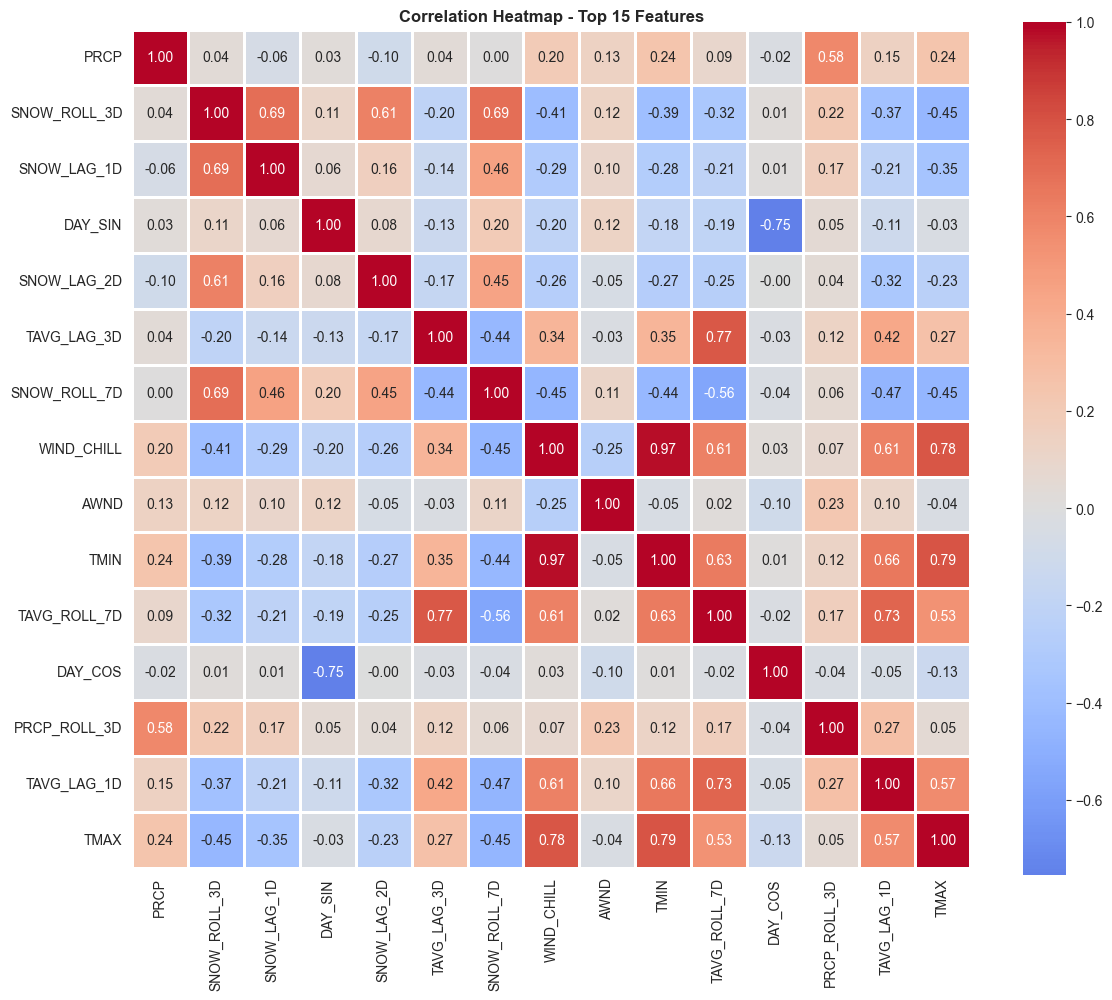

In [10]:
# Check for highly correlated features (multicollinearity)
corr_matrix = df_processed[feature_cols].corr()

# Find pairs with correlation > 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("HIGH CORRELATION PAIRS (>0.9)")
print("="*70)
if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
    print(f"\nFound {len(high_corr_pairs)} highly correlated pairs")
    print("Note: These may cause multicollinearity issues in linear models")
    print("      Neural networks (LSTM) are less affected")
else:
    print("✓ No high correlations found (good!)")

# Visualize correlation heatmap (subset)
top_features = importance.head(15)['feature'].tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df_processed[top_features].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Correlation Heatmap - Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Final Feature Set Summary

In [ ]:
print("="*70)
print("FINAL FEATURE SET FOR LSTM MODEL")
print("="*70)

print(f"\nTotal Features: {len(feature_cols)}")
print("\nFeature Breakdown:")
print(f"  Base Weather: {len(base_features)}")
print(f"  Domain (Wind Chill): {len(domain_features)}")
print(f"  Temporal Encoding: {len(temporal_features)}")
print(f"  Snow-Specific: {len(snow_features)}")
print(f"  Rolling Averages: {len(rolling_features)}")
print(f"  Lag Features: {len(lag_features)}")

print("\nTop 10 Most Important:")
for i, row in importance.head(10).iterrows():
    print(f"  {row['feature']:.<35} {row['importance']:.4f}")

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
insights = [
    "1. Lag features (previous days) are highly important",
    "   → Confirms snowfall has temporal autocorrelation",
    "",
    "2. Rolling averages capture medium-term trends",
    "   → Smooths noise, helps identify patterns",
    "",
    "3. Temperature features strongly correlated",
    "   → Critical for snowfall prediction",
    "",
    "4. Temporal encoding necessary for seasonality",
    "   → Different patterns per month",
    "",
    "5. Domain features (wind chill) add value",
    "   → Real-world physics matters",
    "",
    "6. 25 features provide comprehensive weather representation",
    "   → Balances information vs. complexity",
]
for insight in insights:
    print(insight)

print("\n✓ Feature engineering complete!")

FINAL FEATURE SET FOR LSTM MODEL

Total Features: 25

Feature Breakdown:
  Base Weather: 7
  Domain (Wind Chill): 1
  Temporal Encoding: 6
  Snow-Specific: 5
  Rolling Averages: 6
  Lag Features: 6

Top 10 Most Important:
  PRCP............................... 0.4389
  SNOW_ROLL_3D....................... 0.4167
  SNOW_LAG_1D........................ 0.0206
  DAY_SIN............................ 0.0194
  SNOW_LAG_2D........................ 0.0128
  TAVG_LAG_3D........................ 0.0122
  SNOW_ROLL_7D....................... 0.0104
  WIND_CHILL......................... 0.0096
  AWND............................... 0.0080
  TMIN............................... 0.0075

KEY INSIGHTS
1. Lag features (previous days) are highly important
   → Confirms snowfall has temporal autocorrelation

2. Rolling averages capture medium-term trends
   → Smooths noise, helps identify patterns

3. Temperature features strongly correlated
   → Critical for snowfall prediction

4. Temporal encoding necessary fo